In [11]:
pip install PuLP

Mounted at /content/drive
Status: Optimal

Production Schedule and Results:

2024-11-17 (Profit: $652.00):
  - Part 7 (Cycle Time: 3h, Profit: $210.0)
  - Part 8 (Cycle Time: 2h, Profit: $190.0)
  - Part 9 (Cycle Time: 3h, Profit: $252.0)
  Remaining Materials:
    Steel: 25 units
    Aluminum: 28 units
    Stainless steel: 20 units

2024-11-18 (Profit: $577.50):
  - Part 10 (Cycle Time: 1.5h, Profit: $157.5)
  - Part 20 (Cycle Time: 6h, Profit: $420.0)
  Remaining Materials:
    Steel: 21 units
    Aluminum: 28 units
    Stainless steel: 19 units

2024-11-19 (Profit: $622.00):
  - Part 2 (Cycle Time: 3h, Profit: $252.0)
  - Part 4 (Cycle Time: 5h, Profit: $370.0)
  Remaining Materials:
    Steel: 17 units
    Aluminum: 26 units
    Stainless steel: 19 units

2024-11-20 (Profit: $658.00):
  - Part 1 (Cycle Time: 2h, Profit: $190.0)
  - Part 5 (Cycle Time: 6h, Profit: $468.0)
  Remaining Materials:
    Steel: 14 units
    Aluminum: 23 units
    Stainless steel: 19 units

2024-11-21 (Pro

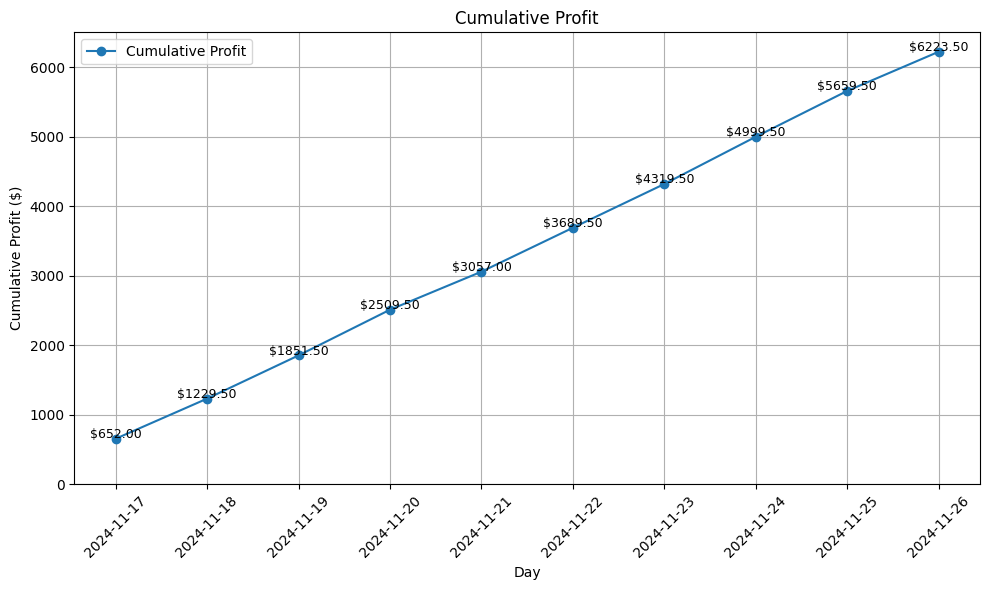

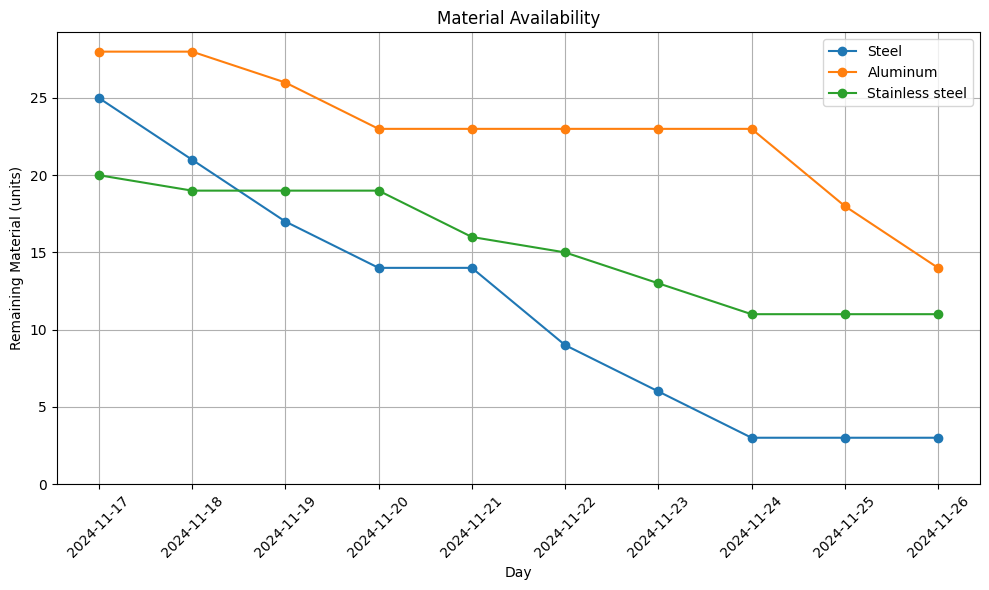

In [12]:
from pulp import LpProblem, LpMaximize, LpVariable, lpSum, LpStatus
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

# Example Data that simulates a machine shop backlog
parts = [
    {"id": 1, "profit": 190.0, "cycle_time": 2, "material": "steel", "material_required": 3},
    {"id": 2, "profit": 252.0, "cycle_time": 3, "material": "aluminum", "material_required": 2},
    {"id": 3, "profit": 157.5, "cycle_time": 1.5, "material": "stainless steel", "material_required": 1},
    {"id": 4, "profit": 370.0, "cycle_time": 5, "material": "steel", "material_required": 4},
    {"id": 5, "profit": 468.0, "cycle_time": 6, "material": "aluminum", "material_required": 3},
    {"id": 6, "profit": 390.0, "cycle_time": 4, "material": "stainless steel", "material_required": 2},
    {"id": 7, "profit": 210.0, "cycle_time": 3, "material": "steel", "material_required": 2},
    {"id": 8, "profit": 190.0, "cycle_time": 2, "material": "steel", "material_required": 3},
    {"id": 9, "profit": 252.0, "cycle_time": 3, "material": "aluminum", "material_required": 2},
    {"id": 10, "profit": 157.5, "cycle_time": 1.5, "material": "stainless steel", "material_required": 1},
    {"id": 11, "profit": 315.0, "cycle_time": 4.5, "material": "steel", "material_required": 3},
    {"id": 12, "profit": 222.0, "cycle_time": 2.5, "material": "aluminum", "material_required": 2},
    {"id": 13, "profit": 352.5, "cycle_time": 3.5, "material": "stainless steel", "material_required": 2},
    {"id": 14, "profit": 475.0, "cycle_time": 6.5, "material": "steel", "material_required": 5},
    {"id": 15, "profit": 564.0, "cycle_time": 7, "material": "aluminum", "material_required": 4},
    {"id": 16, "profit": 195.0, "cycle_time": 2, "material": "stainless steel", "material_required": 1},
    {"id": 17, "profit": 290.0, "cycle_time": 4, "material": "steel", "material_required": 3},
    {"id": 18, "profit": 438.0, "cycle_time": 5.5, "material": "aluminum", "material_required": 3},
    {"id": 19, "profit": 315.0, "cycle_time": 3, "material": "stainless steel", "material_required": 2},
    {"id": 20, "profit": 420.0, "cycle_time": 6, "material": "steel", "material_required": 4},
]

# Resource limitations
resources = {
    "material": {"steel": 30, "aluminum": 30, "stainless steel": 20},
    "working_hours_per_day": 8,
}

# Calculate the minimum number of days needed based on total cycle time
total_cycle_time = sum(part["cycle_time"] for part in parts)
min_days = int(total_cycle_time // resources["working_hours_per_day"]) + 1

# Problem setup
problem = LpProblem("Maximize_Profit_with_Idle_Hour_Minimization", LpMaximize)

# Decision Variables
start_times = {part["id"]: LpVariable(f"Start_Time_{part['id']}", lowBound=0) for part in parts}
completion_flags = {part["id"]: LpVariable(f"Completion_Flag_{part['id']}", cat="Binary") for part in parts}
day_assignments = {
    (part["id"], day): LpVariable(f"Day_Assignment_{part['id']}_Day_{day}", cat="Binary")
    for part in parts
    for day in range(min_days)
}

# Objective Function: Maximize profit
problem += lpSum(part["profit"] * completion_flags[part["id"]] for part in parts), "Maximize_Profit"

# Constraints
# 1. Material availability
for material, available in resources["material"].items():
    problem += (
        lpSum(
            part["material_required"] * completion_flags[part["id"]]
            for part in parts
            if part["material"] == material
        )
        <= available,
        f"Material_Constraint_{material}",
    )

# 2. Each task must be assigned to one day
for part in parts:
    problem += (
        lpSum(day_assignments[(part["id"], day)] for day in range(min_days)) == completion_flags[part["id"]],
        f"Day_Assignment_Constraint_Part_{part['id']}",
    )

# 3. Daily working hours limit
for day in range(min_days):
    problem += lpSum(
        part["cycle_time"] * day_assignments[(part["id"], day)] for part in parts
    ) <= resources["working_hours_per_day"], f"Daily_Working_Hours_Limit_Day_{day}"

# 4. Enforce sequential task filling
for day in range(1, min_days):
    problem += (
        lpSum(day_assignments[(part["id"], day)] for part in parts)
        <= lpSum(day_assignments[(part["id"], day - 1)] for part in parts),
        f"Sequential_Day_Constraint_{day}",
    )

# Solve problem
problem.solve()

# Map results to schedule
start_date = datetime.today()
schedule = {}
profit_per_day = {}
remaining_materials = resources["material"].copy()
daily_remaining_materials = {}
total_profit = 0

# Calculate daily schedules, profit, and update remaining materials
for day in range(min_days):
    current_date = start_date + timedelta(days=day)
    schedule[current_date] = []
    profit_per_day[current_date] = 0

    for part in parts:
        if day_assignments[(part["id"], day)].varValue:
            # Add parts to schedule for specific day
            schedule[current_date].append(
                f"Part {part['id']} (Cycle Time: {part['cycle_time']}h, Profit: ${part['profit']})"
            )
            # Add part profit to total profit per day
            profit_per_day[current_date] += part["profit"]
            # Update total profit
            total_profit += part["profit"]
            # Update remaining materials cumulatively
            remaining_materials[part["material"]] -= part["material_required"]
    # Record the state of remaining materials for the day
    daily_remaining_materials[current_date] = remaining_materials.copy()

# Print Results
print("Status:", LpStatus[problem.status])
print(f"\nProduction Schedule and Results:")

for day, tasks in sorted(schedule.items()):
    # Profit for each day
    profit_today = profit_per_day[day]
    # Remaining material per day
    remaining_material_today = daily_remaining_materials[day]
    print(f"\n{day.strftime('%Y-%m-%d')} (Profit: ${profit_today:.2f}):")
    for task in tasks:
        # Shows which part is scheduled per day
        print(f"  - {task}")
    print("  Remaining Materials:")
    for material, remaining in remaining_material_today.items():
        # Shows material type and amount remaining
        print(f"    {material.capitalize()}: {remaining} units")


print(f"\nTotal Profit: ${total_profit:.2f}")


# Extract data for visualization
profit_data = [profit for profit in profit_per_day.values()]
cumulative_profit = [sum(profit_data[:i+1]) for i in range(len(profit_data))]  # Cumulative profit
material_data = {material: [] for material in resources["material"]}
days = [day.strftime("%Y-%m-%d") for day in profit_per_day.keys()]

# Populate material data for visualization
for day in profit_per_day.keys():
    for material in resources["material"]:
        material_data[material].append(daily_remaining_materials[day][material])

# Chart: Cumulative Profit
plt.figure(figsize=(10, 6))
plt.plot(days, cumulative_profit, marker="o", label="Cumulative Profit")
# Annotate each marker with its actual value
for i, value in enumerate(cumulative_profit):
    plt.text(days[i], value + 10, f"${value:.2f}", ha='center', fontsize=9)

plt.title("Cumulative Profit")
plt.xlabel("Day")
plt.ylabel("Cumulative Profit ($)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()


# Chart: Material Availability
plt.figure(figsize=(10, 6))
for material, values in material_data.items():
    plt.plot(days, values, marker="o", label=material.capitalize())

plt.title("Material Availability")
plt.xlabel("Day")
plt.ylabel("Remaining Material (units)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()



Status: Optimal

Production Schedule and Results:

2024-11-17 (Profit: $600.00):
  - Part 1 (Cycle Time: 2h, Profit: $200)
  - Part 2 (Cycle Time: 3h, Profit: $250)
  - Part 3 (Cycle Time: 1.5h, Profit: $150)
  Remaining Materials:
    Steel: 7 units
    Aluminum: 3 units
    Stainless steel: 2 units

2024-11-18 (Profit: $300.00):
  - Part 4 (Cycle Time: 5h, Profit: $300)
  Remaining Materials:
    Steel: 3 units
    Aluminum: 3 units
    Stainless steel: 2 units

2024-11-19 (Profit: $400.00):
  - Part 5 (Cycle Time: 6h, Profit: $400)
  Remaining Materials:
    Steel: 3 units
    Aluminum: 0 units
    Stainless steel: 2 units

Total Profit: $1300.00


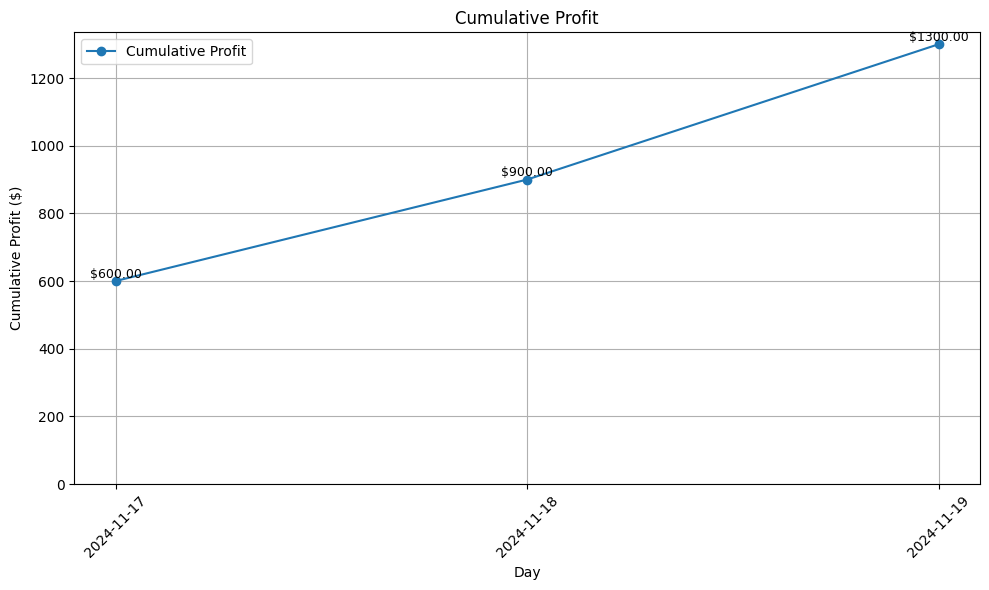

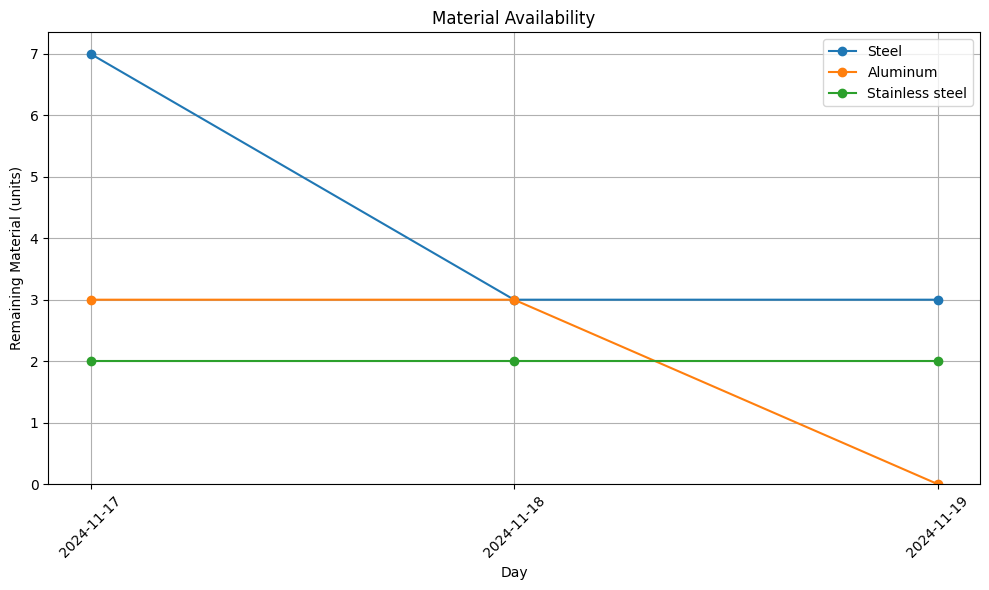

In [13]:
# Example Data that simulates a machine shop backlog
parts = [
    {"id": 1, "profit": 200, "cycle_time": 2, "material": "steel", "material_required": 3},
    {"id": 2, "profit": 250, "cycle_time": 3, "material": "aluminum", "material_required": 2},
    {"id": 3, "profit": 150, "cycle_time": 1.5, "material": "stainless steel", "material_required": 1},
    {"id": 4, "profit": 300, "cycle_time": 5, "material": "steel", "material_required": 4},
    {"id": 5, "profit": 400, "cycle_time": 6, "material": "aluminum", "material_required": 3},
]

# Resource limitations
resources = {
    "material": {"steel": 10, "aluminum": 5, "stainless steel": 3},
    "working_hours_per_day": 8,
}

# Calculate the minimum number of days needed based on total cycle time
total_cycle_time = sum(part["cycle_time"] for part in parts)
min_days = int(total_cycle_time // resources["working_hours_per_day"]) + 1

# Problem setup
problem = LpProblem("Maximize_Profit_with_Idle_Hour_Minimization", LpMaximize)

# Decision Variables
start_times = {part["id"]: LpVariable(f"Start_Time_{part['id']}", lowBound=0) for part in parts}
completion_flags = {part["id"]: LpVariable(f"Completion_Flag_{part['id']}", cat="Binary") for part in parts}
day_assignments = {
    (part["id"], day): LpVariable(f"Day_Assignment_{part['id']}_Day_{day}", cat="Binary")
    for part in parts
    for day in range(min_days)
}

# Objective Function: Maximize profit
problem += lpSum(part["profit"] * completion_flags[part["id"]] for part in parts), "Maximize_Profit"

# Constraints
# 1. Material availability
for material, available in resources["material"].items():
    problem += (
        lpSum(
            part["material_required"] * completion_flags[part["id"]]
            for part in parts
            if part["material"] == material
        )
        <= available,
        f"Material_Constraint_{material}",
    )

# 2. Each task must be assigned to one day
for part in parts:
    problem += (
        lpSum(day_assignments[(part["id"], day)] for day in range(min_days)) == completion_flags[part["id"]],
        f"Day_Assignment_Constraint_Part_{part['id']}",
    )

# 3. Daily working hours limit
for day in range(min_days):
    problem += lpSum(
        part["cycle_time"] * day_assignments[(part["id"], day)] for part in parts
    ) <= resources["working_hours_per_day"], f"Daily_Working_Hours_Limit_Day_{day}"

# 4. Enforce sequential task filling
for day in range(1, min_days):
    problem += (
        lpSum(day_assignments[(part["id"], day)] for part in parts)
        <= lpSum(day_assignments[(part["id"], day - 1)] for part in parts),
        f"Sequential_Day_Constraint_{day}",
    )

# Solve problem
problem.solve()

# Map results to schedule
start_date = datetime.today()
schedule = {}
profit_per_day = {}
remaining_materials = resources["material"].copy()
daily_remaining_materials = {}
total_profit = 0

# Calculate daily schedules, profit, and update remaining materials
for day in range(min_days):
    current_date = start_date + timedelta(days=day)
    schedule[current_date] = []
    profit_per_day[current_date] = 0

    for part in parts:
        if day_assignments[(part["id"], day)].varValue:
            # Add parts to schedule for specific day
            schedule[current_date].append(
                f"Part {part['id']} (Cycle Time: {part['cycle_time']}h, Profit: ${part['profit']})"
            )
            # Add part profit to total profit per day
            profit_per_day[current_date] += part["profit"]
            # Update total profit
            total_profit += part["profit"]
            # Update remaining materials cumulatively
            remaining_materials[part["material"]] -= part["material_required"]
    # Record the state of remaining materials for the day
    daily_remaining_materials[current_date] = remaining_materials.copy()

# Print Results
print("Status:", LpStatus[problem.status])
print(f"\nProduction Schedule and Results:")

for day, tasks in sorted(schedule.items()):
    # Profit for each day
    profit_today = profit_per_day[day]
    # Remaining material per day
    remaining_material_today = daily_remaining_materials[day]
    print(f"\n{day.strftime('%Y-%m-%d')} (Profit: ${profit_today:.2f}):")
    for task in tasks:
        # Shows which part is scheduled per day
        print(f"  - {task}")
    print("  Remaining Materials:")
    for material, remaining in remaining_material_today.items():
        # Shows material type and amount remaining
        print(f"    {material.capitalize()}: {remaining} units")


print(f"\nTotal Profit: ${total_profit:.2f}")


# Extract data for visualization
profit_data = [profit for profit in profit_per_day.values()]
cumulative_profit = [sum(profit_data[:i+1]) for i in range(len(profit_data))]  # Cumulative profit
material_data = {material: [] for material in resources["material"]}
days = [day.strftime("%Y-%m-%d") for day in profit_per_day.keys()]

# Populate material data for visualization
for day in profit_per_day.keys():
    for material in resources["material"]:
        material_data[material].append(daily_remaining_materials[day][material])

# Chart: Cumulative Profit
plt.figure(figsize=(10, 6))
plt.plot(days, cumulative_profit, marker="o", label="Cumulative Profit")
# Annotate each marker with its actual value
for i, value in enumerate(cumulative_profit):
    plt.text(days[i], value + 10, f"${value:.2f}", ha='center', fontsize=9)

plt.title("Cumulative Profit")
plt.xlabel("Day")
plt.ylabel("Cumulative Profit ($)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()


# Chart: Material Availability
plt.figure(figsize=(10, 6))
for material, values in material_data.items():
    plt.plot(days, values, marker="o", label=material.capitalize())

plt.title("Material Availability")
plt.xlabel("Day")
plt.ylabel("Remaining Material (units)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()


In [15]:
%%shell
jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Analysis of Algorithms/Project 2 Machine Shop Optimization.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Analysis of Algorithms/Project 2 Machine Shop Optimization.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 592683 bytes to /content/drive/MyDrive/Colab Notebooks/Analysis of Algorithms/Project 2 Machine Shop Optimization.html
